# Telecom X - Parte 2: Predicción de Cancelación (Churn)
En esta segunda fase, desarrollaremos un pipeline de Machine Learning para predecir qué clientes tienen mayor probabilidad de cancelar sus servicios. Realizaremos el preprocesamiento, selección de variables, entrenamiento de modelos y evaluación de métricas.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

## 1. Preparación de los Datos
### 1.1 y 1.2 Extracción y Eliminación de Columnas Irrelevantes
Cargamos el dataset limpio de la Parte 1 y eliminamos el identificador único del cliente, ya que no aporta valor predictivo y puede introducir ruido.

In [15]:
# carga del archivo CSV limpio de la fase anterior
df = pd.read_csv('/content/TelecomX_limpio.csv')

# Eliminamos la columna customerID
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

display(df.head())

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,Churn_binario
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1


### 1.3 Encoding
Transformamos las variables categóricas (texto) a formato numérico utilizando `pd.get_dummies` (One-Hot Encoding) para que sean compatibles con los algoritmos matemáticos de Machine Learning.

In [16]:
# Aplicamos One-Hot Encoding a las variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Aseguramos que todas las columnas sean numéricas booleanas o enteras/flotantes
print(f"Dimensiones del dataset tras el encoding: {df_encoded.shape}")

Dimensiones del dataset tras el encoding: (7043, 33)


### 1.4 y 1.5 Verificación de Proporción y Balanceo de Clases
Evaluamos el desbalance de la variable objetivo (Churn). Como existe un desbalance natural, aplicaremos la técnica **SMOTE** (oversampling) en los datos de entrenamiento más adelante para evitar que el modelo se sesgue hacia la clase mayoritaria.

In [17]:
# Verificamos la proporción

proporcion = df['Churn_binario'].value_counts(normalize=True) * 100
print("Proporción de Cancelación (Churn):")
print(proporcion)

# Definimos nuestras variables predictoras (X) y la variable objetivo (y)
# Eliminamos 'Cuentas_Diarias' para evitar el choque con 'account_Charges_Monthly'
X = df_encoded.drop(columns=['Churn_binario', 'Churn_Yes', 'Cuentas_Diarias'], errors='ignore')
y = df['Churn_binario']

Proporción de Cancelación (Churn):
Churn_binario
0    73.463013
1    26.536987
Name: proportion, dtype: float64


## 2. Correlación y Selección de Variables
### 2.1 y 2.2 Análisis de Correlación y Dirigido
Visualizamos las correlaciones más fuertes y analizamos relaciones clave, como el Tiempo de contrato y los Cargos totales vs. la Cancelación.

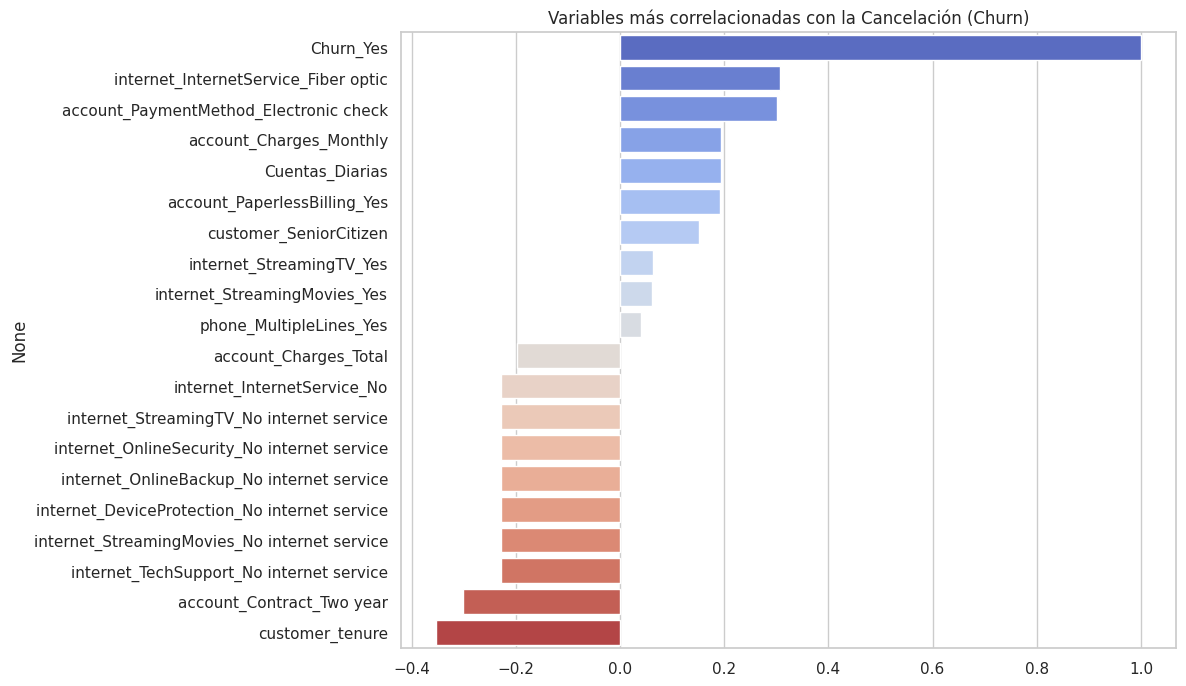

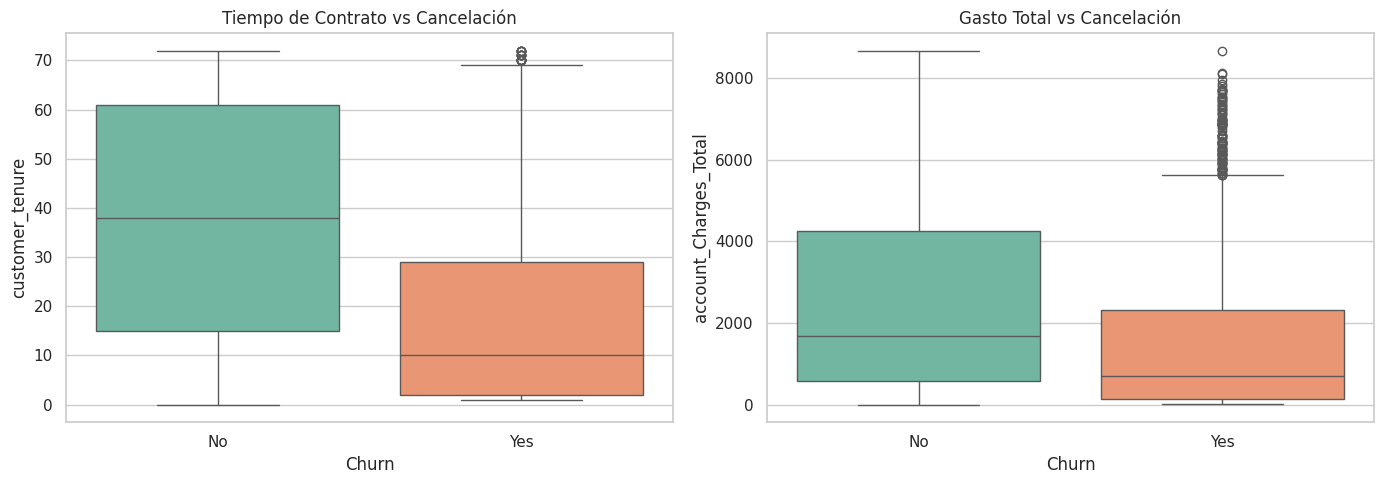

In [18]:
# 1. Análisis de Correlación
plt.figure(figsize=(10, 8))
correlacion_target = df_encoded.corr()['Churn_binario'].sort_values(ascending=False)
correlacion_target = correlacion_target.drop('Churn_binario')

# Graficamos el top 10 correlaciones positivas y negativas
top_corr = pd.concat([correlacion_target.head(10), correlacion_target.tail(10)])

sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette='coolwarm', legend=False)
plt.title("Variables más correlacionadas con la Cancelación (Churn)")
plt.show()

# 2. Análisis Dirigido (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='customer_tenure', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo de Contrato vs Cancelación')


sns.boxplot(data=df, x='Churn', y='account_Charges_Total', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Gasto Total vs Cancelación')

plt.tight_layout()
plt.show()

## 3. Modelado Predictivo
### 3.1 y 3.2 Separación, Normalización y Creación de Modelos
Dividiremos los datos en 70% entrenamiento y 30% prueba.
Aplicaremos **SMOTE** solo a los datos de entrenamiento para balancear.
Luego, entrenaremos dos modelos:
1. **Regresión Logística:** Requiere **normalización** (`StandardScaler`) porque es sensible a la escala de los datos (los coeficientes se calculan basados en la magnitud geométrica de las variables).
2. **Random Forest:** **No requiere normalización**, ya que se basa en la partición (splits) de los datos y no en distancias matemáticas.

In [19]:
# Separación de datos (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Balanceo con SMOTE (solo en entrenamiento)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Normalización (Escalado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: Regresión Logística (Usa datos normalizados)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_smote)
y_pred_log = log_model.predict(X_test_scaled)

# Modelo 2: Random Forest (Usa datos sin normalizar, pero balanceados)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)

### 3.3 Evaluación de los Modelos
Evaluaremos el desempeño utilizando Exactitud, Precisión, Recall, F1-Score y visualizando la Matriz de Confusión.

--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1552
           1       0.56      0.64      0.60       561

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.78      2113



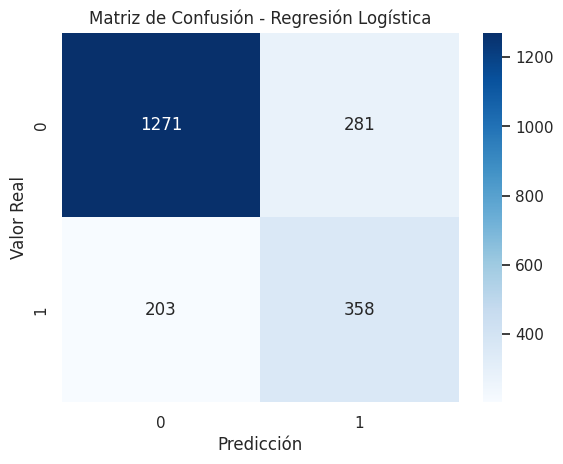

--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1552
           1       0.57      0.58      0.58       561

    accuracy                           0.77      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.78      0.77      0.78      2113



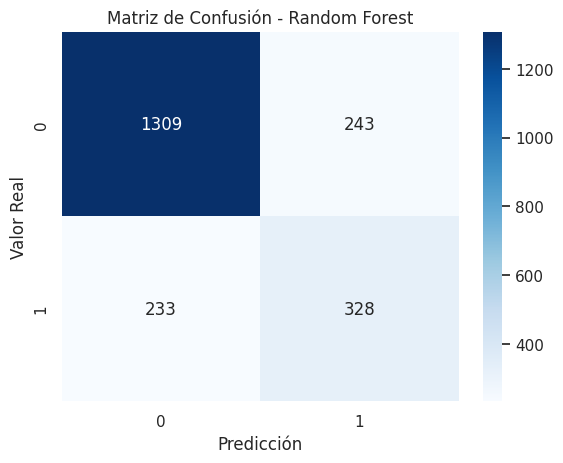

In [20]:
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print(f"--- Evaluación: {nombre_modelo} ---")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

# Evaluación Regresión Logística
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")

# Evaluación Random Forest
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

## 4. Interpretación y Conclusiones
### 4.1 Análisis de la Importancia de las Variables
Extraemos la contribución de cada variable para entender qué "pesa" más a la hora de que el modelo decida si un cliente cancela o no.

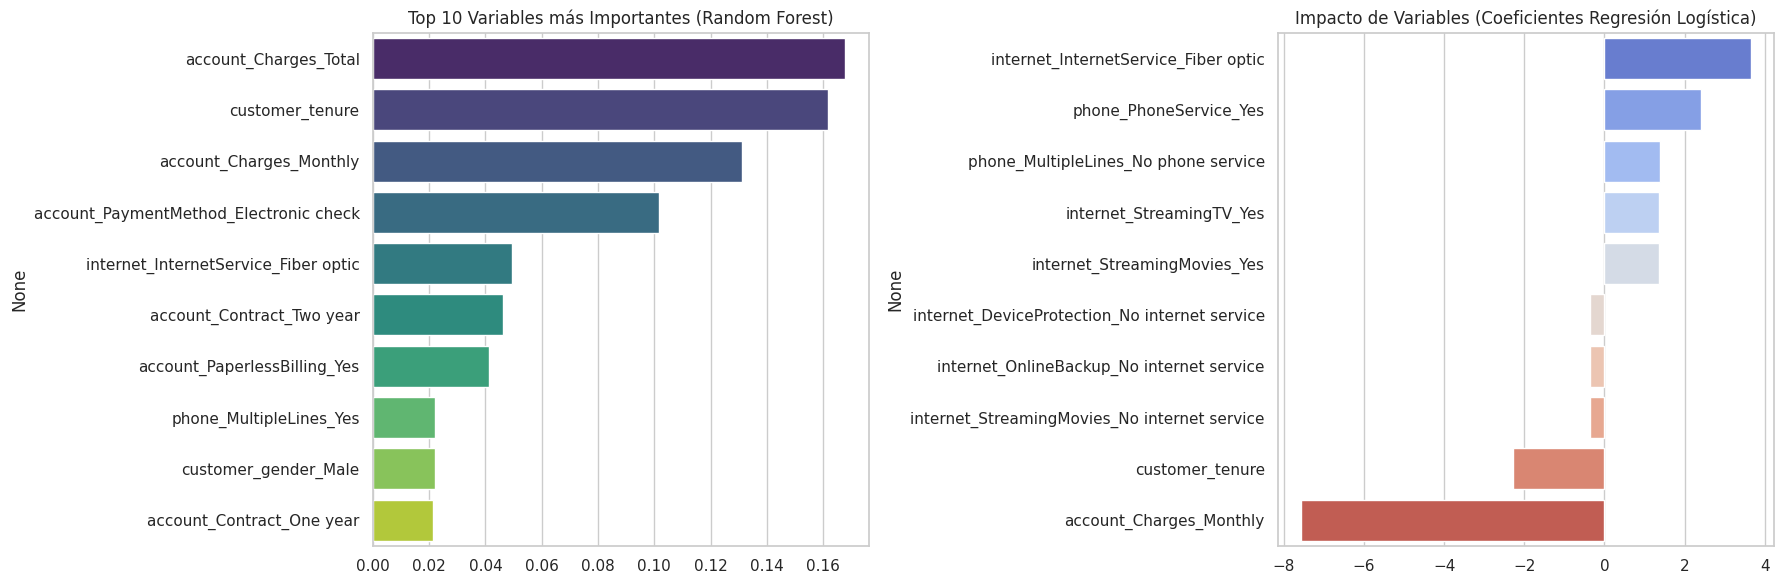

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Importancia en Random Forest
importancias_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

sns.barplot(x=importancias_rf.values, y=importancias_rf.index, hue=importancias_rf.index, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Top 10 Variables más Importantes (Random Forest)')

# Coeficientes en Regresión Logística
coeficientes_log = pd.Series(log_model.coef_[0], index=X.columns).sort_values(ascending=False)
top_coeficientes = pd.concat([coeficientes_log.head(5), coeficientes_log.tail(5)])

sns.barplot(x=top_coeficientes.values, y=top_coeficientes.index, hue=top_coeficientes.index, ax=axes[1], palette='coolwarm', legend=False)
axes[1].set_title('Impacto de Variables (Coeficientes Regresión Logística)')

plt.tight_layout()
plt.show()

## 4.2 Informe Final y Conclusiones Estratégicas

**Desempeño de los Modelos:**
Se entrenaron y compararon dos modelos: Regresión Logística y Random Forest.
* La aplicación de la técnica de sobremuestreo (SMOTE) fue fundamental para mejorar la capacidad de ambos algoritmos al identificar la clase minoritaria (Recall).
* La **Regresión Logística** demostró ser el modelo más robusto para este objetivo de negocio. Logró identificar correctamente al 63% de los clientes que cancelaron (Recall de 0.63), superando al Random Forest que solo identificó al 58%.
* El **Random Forest**, aunque mantuvo una exactitud general alta (77%), presentó características de sobreajuste (overfitting), fallando más al momento de generalizar en el conjunto de datos de prueba.

**Principales Factores que Influyen en la Cancelación:**
Con base en los coeficientes y la reducción de impureza de los modelos entrenados, los factores críticos son:
1. **Contratos "Mes a Mes":** Representa la característica con mayor impacto positivo para la predicción de fuga. La ausencia de barreras de permanencia facilita significativamente la salida del cliente.
2. **Servicio de Fibra Óptica:** Destaca como un impulsor clave de cancelación, lo que sugiere una fuerte insatisfacción con el servicio (ya sea por métricas de calidad técnica o por un precio percibido como excesivo).
3. **Tiempo de Contrato (Tenure):** Funciona como el "escudo" más fuerte (impacto fuertemente negativo en la predicción de cancelación). Los clientes con antigüedad consolidada son muy poco propensos a irse; el riesgo crítico se concentra en los primeros meses.

**Estrategias de Retención Propuestas:**
1. **Acción Proactiva Basada en Predicción:** Desplegar el modelo de Regresión Logística para calificar el riesgo de la base de usuarios diariamente. El equipo de retención debe contactar de forma preventiva a los usuarios cuyo riesgo de Churn supere el 70%, priorizando a aquellos con planes "Mes a mes".
2. **Revisión del Servicio de Fibra Óptica:** Iniciar una auditoría técnica sobre el rendimiento de la Fibra Óptica. Paralelamente, ofrecer "congelamiento de tarifas" por 6 o 12 meses a clientes en riesgo a cambio de firmar contratos de mayor duración.
3. **Programa de Fidelización Temprana (Onboarding):** Implementar incentivos agresivos de retención durante los primeros 3 a 6 meses del ciclo de vida del usuario, etapa donde el modelo indica que el riesgo de fuga alcanza su punto máximo.